In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv(r"./data/iris(k-means_custering).csv")
dataset.head(5)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


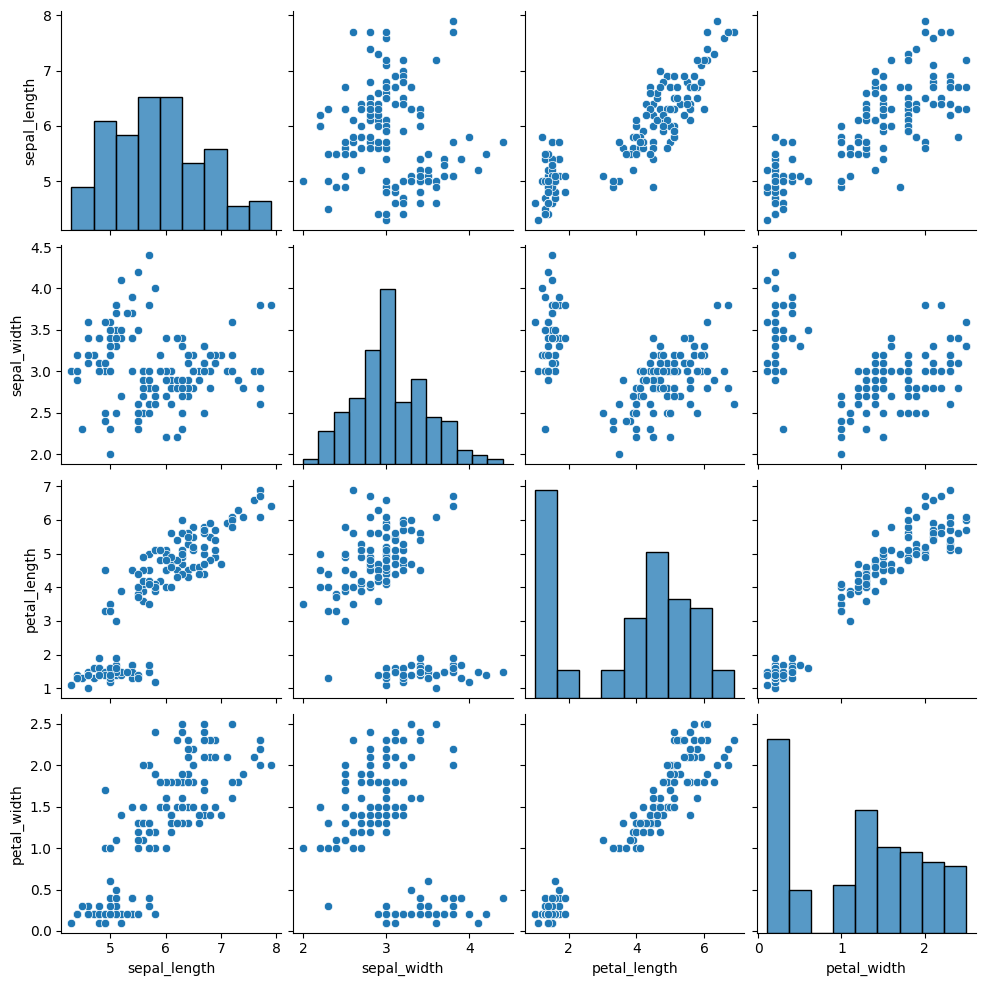

In [3]:
sns.pairplot(data=dataset)
plt.show()

In [4]:
from sklearn.cluster import KMeans

In [6]:
wcss = []
for i in range(2, 21):
    km = KMeans(n_clusters=i, init='k-means++')
    km.fit(dataset)
    wcss.append(km.inertia_)

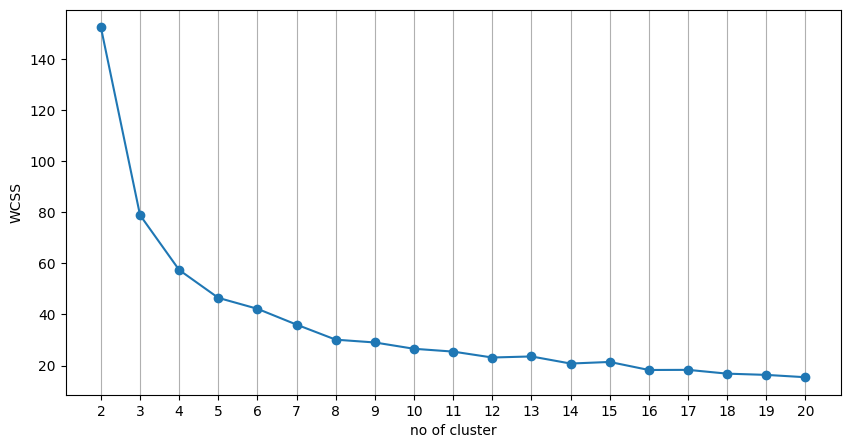

In [7]:
plt.figure(figsize=(10, 5))
plt.plot([i for i in range(2, 21)], wcss, marker="o")
plt.xlabel("no of cluster")
plt.xticks([i for i in range(2, 21)])
plt.ylabel("WCSS")
plt.grid(axis="x")
plt.show()

In [10]:
from sklearn.metrics import silhouette_score

In [8]:
kmn = KMeans(n_clusters=3)
dataset["Predict"] = kmn.fit_predict(dataset)

In [11]:
kmn.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1], dtype=int32)

In [13]:
silhouette_score(dataset, labels=kmn.labels_)

0.6128676734836785

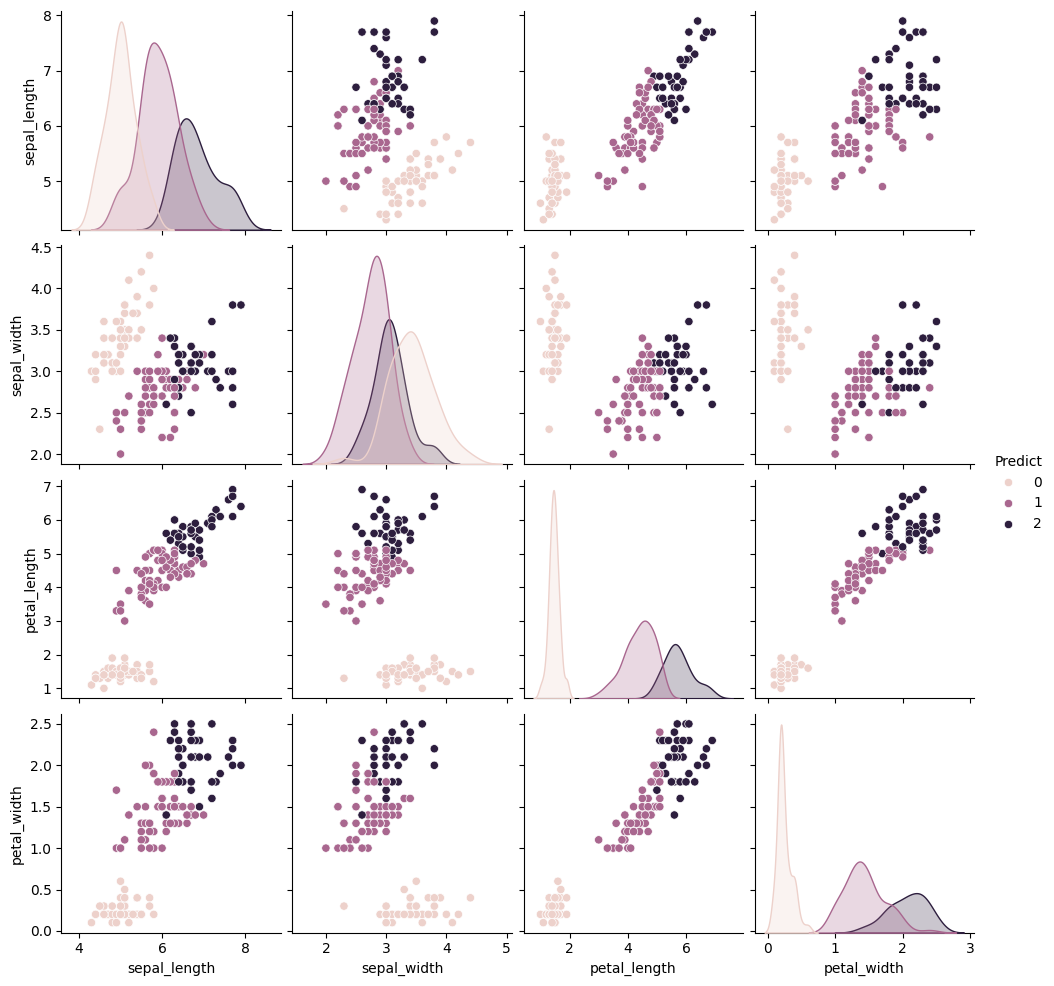

In [9]:
sns.pairplot(data=dataset, hue="Predict")
plt.show()

In [17]:
ss = []
no_c = [j for j in range(2, 21)]
for i in range(2, 21):
    km1 = KMeans(n_clusters=i)
    km1.fit(dataset)
    ss.append(silhouette_score(dataset, labels=km1.labels_))

In [18]:
ss

[0.6812480399631204,
 0.6128676734836785,
 0.5623519391324965,
 0.531912428223798,
 0.40359604513863845,
 0.34459191216187435,
 0.36104918238625794,
 0.31197310016552554,
 0.3263261729553065,
 0.3422498086534578,
 0.3084095429788664,
 0.3098692394082942,
 0.27045792835653704,
 0.2564311393392412,
 0.2486515594184825,
 0.27673472300958724,
 0.30159997386839543,
 0.2615905467474834,
 0.27655111969506596]

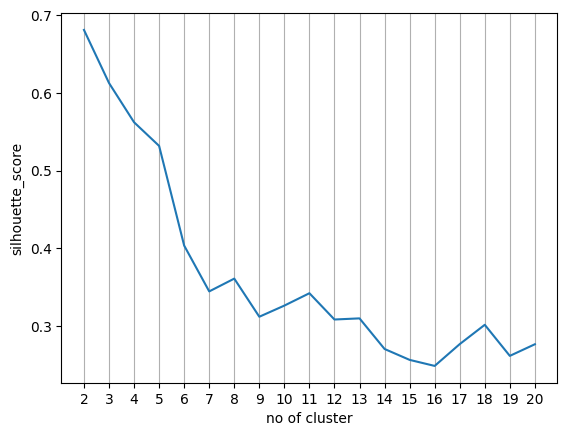

In [21]:
plt.plot(no_c, ss)
plt.xlabel("no of cluster")
plt.ylabel("silhouette_score")
plt.xticks(no_c)
plt.grid(axis="x")
plt.show()